<a href="https://colab.research.google.com/github/Feliz-ua/goit-np-HW-12/blob/main/hw-12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# 1. Імпорт бібліотек та завантаження даних
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score

# 1. Завантаження даних
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

# Стандартизація даних
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

<Figure size 1000x800 with 0 Axes>

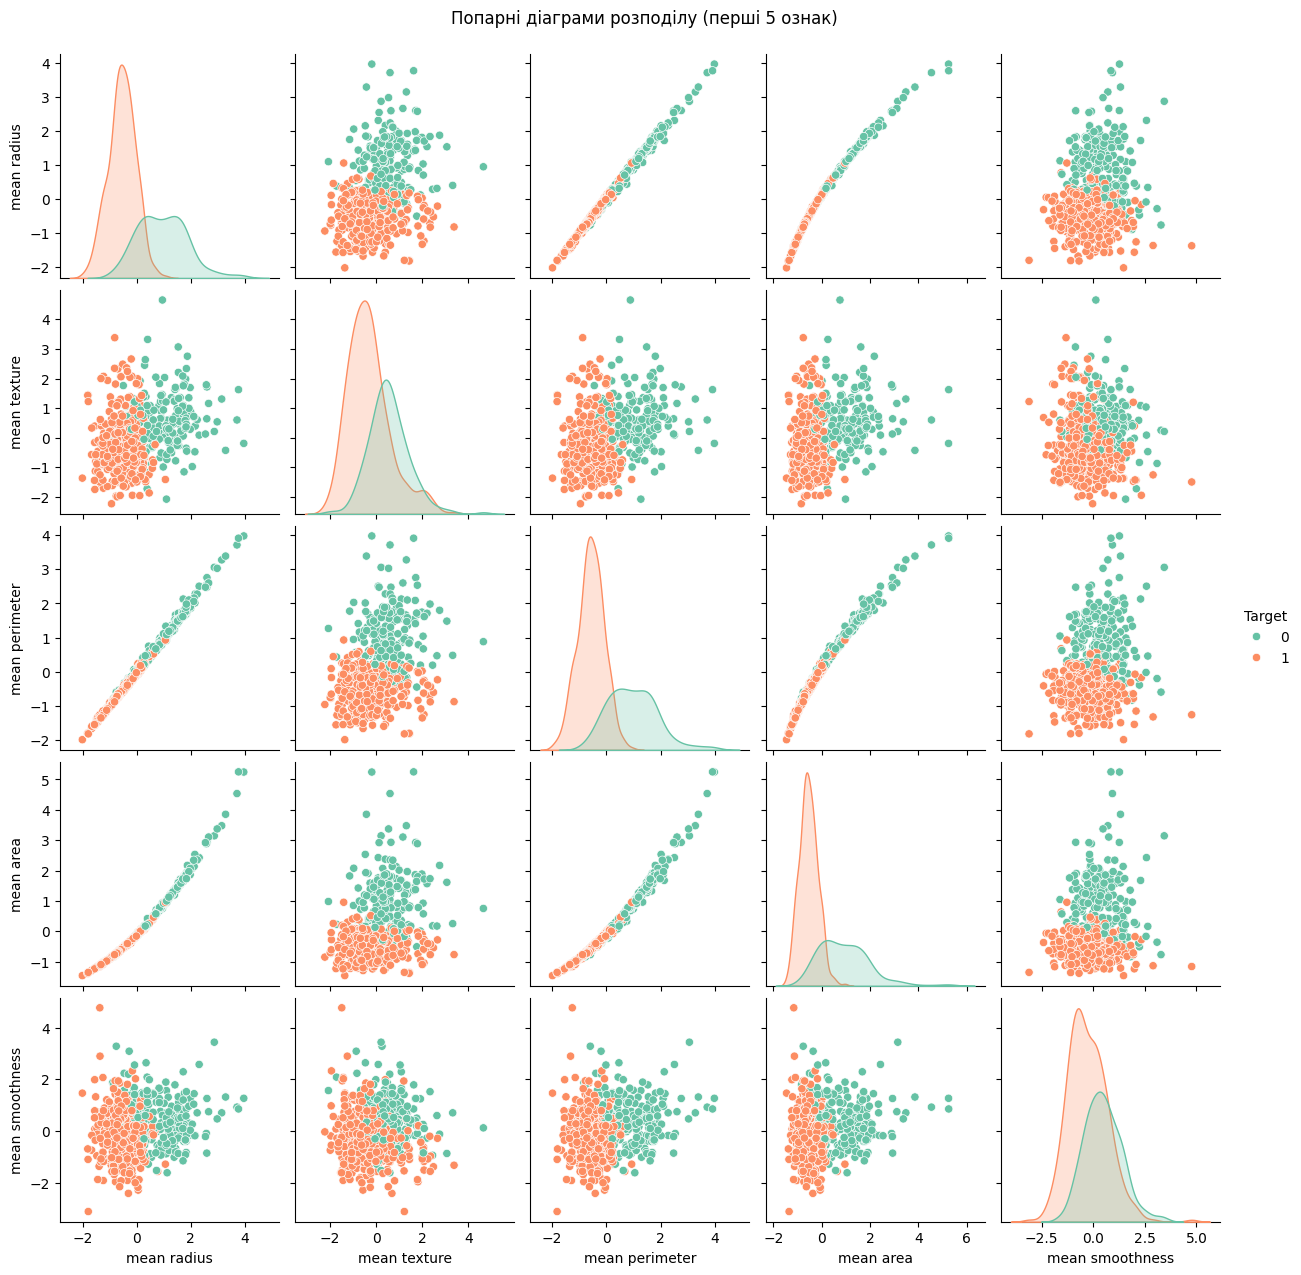

In [6]:
# 2. Візуалізація попарних точкових діаграм
# Формуємо DataFrame для зручності візуалізації
df_vis = pd.DataFrame(X_scaled[:, :5], columns=feature_names[:5])
df_vis['Target'] = y

plt.figure(figsize=(10, 8))
sns.pairplot(df_vis, hue='Target', palette='Set2')
plt.suptitle('Попарні діаграми розподілу (перші 5 ознак)', y=1.02)
plt.show()

In [9]:
# 3. Виконаємо кластеризацію методами (Spectral, KMeans, GMM)
# KMeans
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)

# Спектральна кластерізація
spectral = SpectralClustering(n_clusters=2, random_state=42, affinity='nearest_neighbors')
y_spectral = spectral.fit_predict(X_scaled)

# Модель гаусових сумішей (GMM)
gmm = GaussianMixture(n_components=2, random_state=42)
y_gmm = gmm.fit_predict(X_scaled)

def check_cluster_accuracy(y_true, y_pred):
    acc1 = accuracy_score(y_true, y_pred)
    acc2 = accuracy_score(y_true, 1 - y_pred) # Інвертовані мітки
    return max(acc1, acc2)

print(f"Збіг KMeans з реальними мітками: {check_cluster_accuracy(y, y_kmeans):.4f}")
print(f"Збіг Спектральеная кластерізація з реальними мітками: {check_cluster_accuracy(y, y_spectral):.4f}")
print(f"Збіг GMM з реальними мітками: {check_cluster_accuracy(y, y_gmm):.4f}")

Збіг KMeans з реальними мітками: 0.9051
Збіг Спектральеная кластерізація з реальними мітками: 0.9367
Збіг GMM з реальними мітками: 0.9402


**Пояснення результатів:**

 Високий відсоток збігу показує, що хворі (злоякісні) та здорові (доброякісні) клітини настільки сильно відрізняються одна від одної, що алгоритми здатний самостійно правильно розсортувати їх на дві відповідні групи.

In [12]:
# 4. Зменшення розмірності з 30 ознак до 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

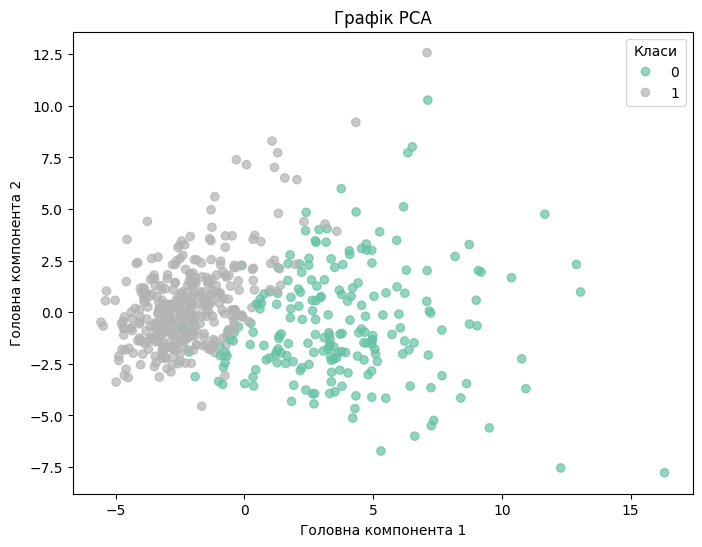

In [16]:
# 5. Візуаліція за класами у новому просторі ознак
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='Set2', alpha=0.7)
plt.title('Графік PCA')
plt.xlabel('Головна компонента 1')
plt.ylabel('Головна компонента 2')
plt.legend(*scatter.legend_elements(), title="Класи")
plt.show()


In [ ]:
# 6. Класифікацію методом логістичної регресії LogisticRegression з бібліотеки sklearn.
